<div style="background: linear-gradient(135deg, #d8b4fe 0%, #c4b5fd 50%, #a78bfa 100%); border-radius: 16px; padding: 36px 40px; text-align: center; box-shadow: 0 4px 20px rgba(167,139,250,0.4); margin-bottom: 10px;">
<h1 style="color: #3b0764; font-size: 2.2em; font-weight: 800; margin: 0 0 10px 0; text-shadow: 1px 1px 3px rgba(255,255,255,0.5);">
🧠 Step 03 — Feature Engineering, Vectorization &amp; Classical Modeling
</h1>
<p style="color: #4c1d95; font-size: 1.1em; margin: 0; font-weight: 500;">
Comparaison de modèles robustes (NaiveBayes · LogisticRegression · SVM · <b>XGBoost</b>) sur 3 méthodes de vectorisation : <b>TF-IDF</b> · <b>Bag-of-Words</b> · <b>Word2Vec</b>
</p>
</div>

In [25]:
# Installation des librairies optionnelles
!pip install gensim emoji contractions ftfy -q
!pip install xgboost -q


In [44]:
# === IMPORTS ET INITIALISATION ===
import os
import re
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

import joblib
import emoji
import contractions
import ftfy
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

# NLTK data
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Configuration
RANDOM_STATE = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("✓ Toutes les librairies importées avec succès")
from xgboost import XGBClassifier



✓ Toutes les librairies importées avec succès


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hil\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [27]:
# === CHARGEMENT ET NETTOYAGE DES DONNÉES ===
DATA_PATH = "data.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset chargé : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}")

# Nettoyage basique
df = df.dropna()
df = df.drop_duplicates()
df = df[df["statement"].str.len() > 3]

# Suppression des classes problématiques
classes_to_remove = ["personality disorder", "bipolar"]
df = df[~df["status"].isin(classes_to_remove)]

print(f"✓ Dataset nettoyé : {df.shape}")
print(f"✓ Classes : {df['status'].unique()}")
print(f"✓ Distribution avant cap :")
display(df['status'].value_counts())


Dataset chargé : (53043, 3)
Colonnes : ['Unnamed: 0', 'statement', 'status']
✓ Dataset nettoyé : (52667, 3)
✓ Classes : ['Anxiety' 'Normal' 'Depression' 'Suicidal' 'Stress' 'Bipolar'
 'Personality disorder']
✓ Distribution des classes :


status
Normal                  16330
Depression              15403
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64

<div style="background:#FDE8F5;border-left:4px solid #C026A0;padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0">
<b style="color:#831843">🔧 CHANGE 1 — Cap à 2000 exemples par classe</b><br><span style="font-size:12px;color:#9D174D">Chaque classe est limitée à 2000 exemples pour équilibrer le dataset et réduire le temps d'entraînement.</span>
</div>

In [ ]:
# ── CHANGE 1 : CAP À 2000 EXEMPLES PAR CLASSE ──────────────────────────────
# Sélection NON aléatoire : on garde uniquement les textes de qualité.
# Critères :
#   - texte non vide (après strip)
#   - au moins 4 mots (word count > 3)
# Parmi les textes qui passent les critères, shuffle reproductible puis cap.

MAX_PER_CLASS = 2000

def quality_filter(g, max_n=MAX_PER_CLASS, seed=42):
    non_vide = g["statement"].str.strip().str.len() > 0
    assez_long = g["statement"].str.split().str.len() > 3
    g_clean = g[non_vide & assez_long].copy()
    g_clean = g_clean.sample(frac=1, random_state=seed)
    return g_clean.head(max_n)

df = (
    df.groupby("status", group_keys=False)
      .apply(quality_filter)
      .reset_index(drop=True)
)

print(f"✓ Dataset après cap ({MAX_PER_CLASS}/classe, textes qualité) : {df.shape}")
print(f"✓ Textes vides restants  : {df['statement'].str.strip().eq('').sum()}")
print(f"✓ Textes <= 3 mots restants : {(df['statement'].str.split().str.len() <= 3).sum()}")
print(f"\n✓ Distribution des classes :")
display(df["status"].value_counts())


<div style="background:#FDE8F5;border-left:4px solid #C026A0;padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0">
<b style="color:#831843">🔧 CHANGE 2 — Emojis → nombres de sentiment (-1 / 0 / +1)</b><br><span style="font-size:12px;color:#9D174D">Au lieu de convertir les emojis en texte (ex: "sad_face"), ils sont remplacés par un score numérique : positif=+1, négatif=-1. Cela préserve l'information émotionnelle sous forme numérique directement exploitable par les modèles.</span>
</div>

In [28]:
# === PREPROCESSING DU TEXTE ===
# (Voir CHANGE 2 — emojis remplacés par -1 / 0 / +1)
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize

# Download required NLTK data
for resource in ['stopwords', 'wordnet', 'averaged_perceptron_tagger', 'punkt', 'punkt_tab', 'omw-1.4']:
    try:
        nltk.data.find(f'tokenizers/{resource}' if 'punkt' in resource else
                       f'taggers/{resource}' if 'tagger' in resource else
                       f'corpora/{resource}')
    except LookupError:
        nltk.download(resource, quiet=True)

def get_wordnet_pos(treebank_tag):
    """Convert POS tag to WordNet format for accurate lemmatization."""
    from nltk.corpus import wordnet
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default to noun

def preprocess(X):
    X = pd.DataFrame({"statement": X})

    # 1. Unicode fix FIRST (before any transformation alters the encoding)
    X["statement"] = X["statement"].apply(lambda x: ftfy.fix_text(str(x)))

    # 2. Contractions BEFORE lowercase (works better on original casing)
    X["statement"] = X["statement"].apply(lambda x: contractions.fix(x))

    # 3. Lowercase
    X["statement"] = X["statement"].apply(lambda x: x.lower())

    # 4. URLs → remove entirely (placeholder <URL> pollutes vocabulary)
    X["statement"] = X["statement"].apply(
        lambda x: re.sub(r"https?://\S+|www\.\S+", " ", x)
    )

    # 5. Mentions → remove entirely
    X["statement"] = X["statement"].apply(
        lambda x: re.sub(r"@\w+", " ", x)
    )

    # 6. Hashtags → keep the word, remove the #
    X["statement"] = X["statement"].apply(
        lambda x: re.sub(r"#(\w+)", r"\1", x)
    )

    # 7. Emojis → sentiment number (-1, 0, +1)
    # CHANGE 2: instead of text labels (sad_face, etc.), emojis are replaced
    # by a sentiment score number: positive=+1, negative=-1, neutral=0
    POSITIVE_EMOJIS = set([
        "😀","😃","😄","😁","😆","😊","🙂","😍","🥰","😘","😗","😙","😚",
        "🤗","😎","🥳","😸","😺","🎉","❤️","💕","💖","💗","💓","💞","💯",
        "👍","✨","🌟","⭐","🌈","🎊","😇","🤩","🥹","💪","🙌","👏"
    ])
    NEGATIVE_EMOJIS = set([
        "😢","😭","😔","😞","😟","😕","🙁","☹️","😣","😖","😫","😩","😰",
        "😥","😓","😿","💔","😤","😠","😡","🤬","😈","👿","💀","☠️","😱",
        "😨","😧","😦","🥺","😮‍💨","😶‍🌫️","🫠","😵","🤯","🥴","😷","🤒","🤕"
    ])

    def replace_emojis_with_number(text):
        result = []
        i = 0
        while i < len(text):
            # Try 2-char emoji first, then 1-char
            found = False
            for length in [2, 1]:
                char = text[i:i+length]
                if char in POSITIVE_EMOJIS:
                    result.append(" 1 ")
                    i += length
                    found = True
                    break
                elif char in NEGATIVE_EMOJIS:
                    result.append(" -1 ")
                    i += length
                    found = True
                    break
            if not found:
                result.append(text[i])
                i += 1
        return "".join(result)

    X["statement"] = X["statement"].apply(replace_emojis_with_number)

    # Remove any remaining non-text emojis using regex (catch-all)
    X["statement"] = X["statement"].apply(
        lambda x: re.sub(r'[^\x00-\x7F]+', ' ', x)
    )

    # 8. Slang dictionary (defined once, not inside lambda)
    slang_dict = {
        "u": "you", "ur": "your", "idk": "i do not know", "lol": "laughing",
        "omg": "oh my god", "wtf": "what the fuck", "rn": "right now",
        "bc": "because", "cuz": "because", "gonna": "going to", "wanna": "want to",
        "thx": "thanks", "pls": "please", "plz": "please", "ngl": "not going to lie",
        "imo": "in my opinion", "tbh": "to be honest", "smh": "shaking my head",
        "brb": "be right back", "gtg": "got to go", "afk": "away from keyboard",
        "irl": "in real life", "fwiw": "for what it is worth"
    }
    X["statement"] = X["statement"].apply(
        lambda x: " ".join([slang_dict.get(word, word) for word in x.split()])
    )

    # 9. Repeated punctuation normalization
    X["statement"] = X["statement"].apply(
        lambda x: re.sub(r"!{2,}", "!", re.sub(r"\?{2,}", "?", x))
    )

    # 10. Remove digits and special characters (digits add noise in mental health text)
    X["statement"] = X["statement"].apply(
        lambda x: re.sub(r"[^a-z\s'!?]", " ", x)
    )

    # 11. Lemmatization with POS tagging (multi-POS: nouns, verbs, adj, adv)
    lemmatizer = WordNetLemmatizer()
    def lemmatize_with_pos(text):
        tokens = word_tokenize(text)
        pos_tags = pos_tag(tokens)
        return " ".join([
            lemmatizer.lemmatize(word, get_wordnet_pos(tag))
            for word, tag in pos_tags
        ])
    X["statement"] = X["statement"].apply(lemmatize_with_pos)

    # 12. Stopwords AFTER lemmatization (preserving key negations)
    negation_words = {"not", "no", "nor", "never", "cannot", "n't"}
    stop_words = set(stopwords.words("english")) - negation_words
    X["statement"] = X["statement"].apply(
        lambda x: " ".join([word for word in x.split() if word not in stop_words])
    )

    # 13. Extra whitespace cleanup
    X["statement"] = X["statement"].apply(lambda x: " ".join(x.split()))

    # 14. Filter out empty or too-short texts
    mask = X["statement"].fillna("").astype(str).str.strip().str.len() > 2
    X = X[mask].copy()
    kept_idx = X.index.to_numpy()

    print(f"✓ Preprocessing terminé. Shape finale : {X.shape}")
    return X["statement"].to_numpy(), kept_idx

# Extraction X / y
TEXT_COL = "statement"
LABEL_COL = "status"

X = df[TEXT_COL].values
y = df[LABEL_COL].values

# Apply preprocessing
X, kept_idx = preprocess(X)
y = y[kept_idx]

print(f"✓ X shape: {X.shape}")
print(f"✓ y shape: {y.shape}")


✓ Preprocessing terminé. Shape finale : (52625, 1)
✓ X shape: (52625,)
✓ y shape: (52625,)


In [29]:
df.shape

(52667, 3)

In [30]:
# === TRAIN / VALIDATION / TEST SPLIT (70/15/15) ===
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print(f"Train: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")

# Verify stratification
split_summary = pd.DataFrame({
    "train": pd.Series(y_train).value_counts(normalize=True).sort_index(),
    "validation": pd.Series(y_val).value_counts(normalize=True).sort_index(),
    "test": pd.Series(y_test).value_counts(normalize=True).sort_index()
}).round(4) * 100

print("\n✓ Distribution stratifiée (%) :")
display(split_summary)

# Label encoding
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

print("\n✓ Label mapping:")
display(pd.DataFrame({
    "classe": label_encoder.classes_,
    "encoded": range(len(label_encoder.classes_))
}))

Train: 36837 | Validation: 7894 | Test: 7894

✓ Distribution stratifiée (%) :


,train,validation,test
Anxiety,7.30,7.30,7.30
Bipolar,5.28,5.27,5.28
Depression,29.27,29.28,29.26
Normal,30.96,30.95,30.96
Personality disorder,2.05,2.05,2.04
Stress,4.92,4.92,4.92
Suicidal,20.24,20.24,20.24



✓ Label mapping:


,classe,encoded
0,Anxiety,0
1,Bipolar,1
2,Depression,2
3,Normal,3
4,Personality disorder,4
5,Stress,5
6,Suicidal,6


In [31]:
# === FONCTION D'ÉVALUATION COMMUNE ===
def evaluate_model(model_name, vectorizer_name, model, X_eval, y_eval_enc, label_encoder):
    """Évalue un modèle sur X_eval et retourne les métriques."""
    try:
        y_pred = model.predict(X_eval)
    except:
        if vectorizer_name == "TF-IDF":
            X_eval = tfidf_probe.transform(X_eval)
        elif vectorizer_name.lower() == "bow":
            if hasattr(model, "named_steps") and "bow" in model.named_steps:
                X_eval = model.named_steps["bow"].transform(X_eval)
        y_pred = model.predict(X_eval)

    accuracy = accuracy_score(y_eval_enc, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_eval_enc, y_pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_eval_enc, y_pred, average="weighted", zero_division=0
    )

    return {
        "vectorizer": vectorizer_name,
        "model": model_name,
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted
    }, y_pred

print("✓ Fonction d'évaluation définie")

✓ Fonction d'évaluation définie


In [43]:
# === PARTIE A : TF-IDF VECTORIZATION ===
# TF-IDF probe pour évaluation
tfidf_probe = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.90,
    sublinear_tf=True,
    token_pattern=r"\b[a-zA-Z']{2,}\b"
)
X_train_tfidf = tfidf_probe.fit_transform(X_train)

print(f"TF-IDF Shape: {X_train_tfidf.shape}")
print(f"Vocabulaire: {len(tfidf_probe.get_feature_names_out())} features")

# Définir les pipelines TF-IDF
tfidf_pipelines = {}

tfidf_pipelines["TFIDF_NaiveBayes"] = {
    "pipeline": ImbPipeline([
        ("tfidf", TfidfVectorizer(token_pattern=r"\b[a-zA-Z']{2,}\b", sublinear_tf=True)),
        ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
        ("clf", MultinomialNB())
    ]),
    "params": {
        "tfidf__max_features": [5000, 10000, 15000],
        "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
        "tfidf__min_df": [1, 2],
        "tfidf__max_df": [0.85, 0.90, 0.95],
        "clf__alpha": [0.01, 0.1, 0.5, 1.0]
    }
}

tfidf_pipelines["TFIDF_LogisticRegression"] = {
    "pipeline": ImbPipeline([
        ("tfidf", TfidfVectorizer(token_pattern=r"\b[a-zA-Z']{2,}\b", sublinear_tf=True)),
        ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    "params": {
        "tfidf__max_features": [5000, 10000, 15000],
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "tfidf__min_df": [1, 2],
        "tfidf__max_df": [0.85, 0.90, 0.95],
        "clf__C": [0.01, 0.1, 0.5, 1.0, 2.0]
    }
}

tfidf_pipelines["TFIDF_SVM"] = {
    "pipeline": ImbPipeline([
        ("tfidf", TfidfVectorizer(token_pattern=r"\b[a-zA-Z']{2,}\b", sublinear_tf=True)),
        ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
        ("clf", LinearSVC(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "params": {
        "tfidf__max_features": [5000, 10000, 15000],
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "tfidf__min_df": [1, 2],
        "tfidf__max_df": [0.85, 0.90, 0.95],
        "clf__C": [0.01, 0.1, 0.5, 1.0, 2.0]
    }
}

# Entraînement TF-IDF
tfidf_results = []
trained_tfidf_models = {}
tfidf_predictions_val = {}

for name, config in tfidf_pipelines.items():
    print(f"\nEntraînement: {name}")
    start_time = time.time()

    grid = RandomizedSearchCV(
        estimator=config["pipeline"],
        param_distributions=config["params"],
        n_iter=10,
        scoring="f1_macro",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train_enc)
    elapsed = time.time() - start_time

    print(f"  Best CV F1: {grid.best_score_:.4f} | Time: {elapsed:.0f}s")

    best_model = grid.best_estimator_
    result, y_pred_val = evaluate_model(
        model_name=name.replace("TFIDF_", ""),
        vectorizer_name="TF-IDF",
        model=best_model,
        X_eval=X_val,
        y_eval_enc=y_val_enc,
        label_encoder=label_encoder
    )

    result["best_cv_f1_macro"] = grid.best_score_
    result["training_time_sec"] = elapsed

    tfidf_results.append(result)
    trained_tfidf_models[name] = best_model
    tfidf_predictions_val[name] = y_pred_val

# Résultats TF-IDF
if tfidf_results:
    tfidf_results_df = pd.DataFrame(tfidf_results).sort_values(by="f1_macro", ascending=False)
    print("\n✓ Résultats TF-IDF:")
    display(tfidf_results_df[["model", "f1_macro", "accuracy", "best_cv_f1_macro"]])
else:
    tfidf_results_df = pd.DataFrame()


TF-IDF Shape: (36837, 10000)
Vocabulaire: 10000 features

Entraînement: TFIDF_NaiveBayes
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  Best CV F1: 0.5637 | Time: 300s

Entraînement: TFIDF_LogisticRegression
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  Best CV F1: 0.7024 | Time: 479s

Entraînement: TFIDF_SVM
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  Best CV F1: 0.6909 | Time: 1065s

✓ Résultats TF-IDF:


,model,f1_macro,accuracy,best_cv_f1_macro
1,LogisticRegression,0.706931,0.749303,0.702437
2,SVM,0.687752,0.736002,0.690880
0,NaiveBayes,0.568441,0.630859,0.563707


In [ ]:
# === XGBoost — TF-IDF VECTORIZATION ===
tfidf_pipelines["TFIDF_XGBoost"] = {
    "pipeline": ImbPipeline([
        ("tfidf", TfidfVectorizer(token_pattern=r"\b[a-zA-Z']{2,}\b", sublinear_tf=True)),
        ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
        ("clf", XGBClassifier(
            eval_metric="mlogloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0
        ))
    ]),
    "params": {
        "tfidf__max_features": [5000, 10000],
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [4, 6],
        "clf__learning_rate": [0.05, 0.1],
        "clf__subsample": [0.8, 1.0]
    }
}

print("\nEntraînement: TFIDF_XGBoost")
start_time = time.time()

grid_xgb_tfidf = RandomizedSearchCV(
    estimator=tfidf_pipelines["TFIDF_XGBoost"]["pipeline"],
    param_distributions=tfidf_pipelines["TFIDF_XGBoost"]["params"],
    n_iter=10,
    scoring="f1_macro",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

grid_xgb_tfidf.fit(X_train, y_train_enc)
elapsed = time.time() - start_time
print(f"  Best CV F1: {grid_xgb_tfidf.best_score_:.4f} | Time: {elapsed:.0f}s")

best_xgb_tfidf = grid_xgb_tfidf.best_estimator_
result_xgb_tfidf, y_pred_xgb_tfidf = evaluate_model(
    model_name="XGBoost",
    vectorizer_name="TF-IDF",
    model=best_xgb_tfidf,
    X_eval=X_val,
    y_eval_enc=y_val_enc,
    label_encoder=label_encoder
)

result_xgb_tfidf["best_cv_f1_macro"] = grid_xgb_tfidf.best_score_
result_xgb_tfidf["training_time_sec"] = elapsed

tfidf_results.append(result_xgb_tfidf)
trained_tfidf_models["TFIDF_XGBoost"] = best_xgb_tfidf
tfidf_predictions_val["TFIDF_XGBoost"] = y_pred_xgb_tfidf

tfidf_results_df = pd.DataFrame(tfidf_results).sort_values(by="f1_macro", ascending=False)
print("\n✓ Résultats TF-IDF (avec XGBoost):")
display(tfidf_results_df[["model", "f1_macro", "accuracy", "best_cv_f1_macro"]])


In [33]:
# === PARTIE B : BAG-OF-WORDS VECTORIZATION ===
bow_pipelines = {}

bow_pipelines["BOW_NaiveBayes"] = {
    "pipeline": ImbPipeline([
        ("bow", CountVectorizer(max_features=5000, token_pattern=r"\b[a-zA-Z']{2,}\b")),
        ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
        ("clf", MultinomialNB())
    ]),
    "params": {
        "bow__max_features": [3000, 5000, 10000],
        "bow__ngram_range": [(1, 1), (1, 2)],
        "bow__min_df": [1, 2],
        "clf__alpha": [0.01, 0.1, 0.5, 1.0]
    }
}

bow_pipelines["BOW_LogisticRegression"] = {
    "pipeline": ImbPipeline([
        ("bow", CountVectorizer(token_pattern=r"\b[a-zA-Z']{2,}\b")),
        ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    "params": {
        "bow__max_features": [3000, 5000, 10000],
        "bow__ngram_range": [(1, 1), (1, 2)],
        "bow__min_df": [1, 2],
        "clf__C": [0.01, 0.1, 0.5, 1.0]
    }
}

print("✓ Pipelines defined for Bag-of-Words (CountVectorizer).")

# Training loop (RandomizedSearchCV)
bow_results = []
trained_bow_models = {}
bow_predictions_val = {}

for name, config in bow_pipelines.items():
    print(f"\nEntraînement: {name}")
    start_time = time.time()

    grid = RandomizedSearchCV(
        estimator=config["pipeline"],
        param_distributions=config["params"],
        n_iter=10,
        scoring="f1_macro",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
    )

    grid.fit(X_train, y_train_enc)

    elapsed = time.time() - start_time
    print(f"✓ Best params: {grid.best_params_}")
    print(f"✓ Best CV macro F1: {grid.best_score_:.4f}")
    print(f"✓ Training time: {elapsed:.0f}s")

    best_model = grid.best_estimator_
    result, y_pred_val = evaluate_model(
        model_name=name.replace("BOW_", ""),
        vectorizer_name="BOW",
        model=best_model,
        X_eval=X_val,
        y_eval_enc=y_val_enc,
        label_encoder=label_encoder
    )

    result["best_cv_f1_macro"] = grid.best_score_
    result["training_time_sec"] = elapsed
    result["best_params"] = str(grid.best_params_)

    bow_results.append(result)
    trained_bow_models[name] = best_model
    bow_predictions_val[name] = y_pred_val

# Compile results
bow_results_df = pd.DataFrame(bow_results).sort_values(by="f1_macro", ascending=False)
display(bow_results_df)

✓ Pipelines defined for Bag-of-Words (CountVectorizer).

Entraînement: BOW_NaiveBayes
Fitting 5 folds for each of 30 candidates, totalling 150 fits
✓ Best params: {'clf__alpha': 0.5, 'bow__ngram_range': (1, 1), 'bow__min_df': 1, 'bow__max_features': 10000}
✓ Best CV macro F1: 0.5530
✓ Training time: 116s

Entraînement: BOW_LogisticRegression
Fitting 5 folds for each of 30 candidates, totalling 150 fits
✓ Best params: {'clf__C': 0.1, 'bow__ngram_range': (1, 2), 'bow__min_df': 1, 'bow__max_features': 10000}
✓ Best CV macro F1: 0.6788
✓ Training time: 1432s


,vectorizer,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,best_cv_f1_macro,training_time_sec,best_params
1,BOW,LogisticRegression,0.737395,0.672967,0.702789,0.684663,0.739672,0.737395,0.735380,0.678842,1432.306056,"{'clf__C': 0.1, 'bow__ngram_range': (1, 2), 'b..."
0,BOW,NaiveBayes,0.614771,0.532233,0.630038,0.554435,0.669285,0.614771,0.624865,0.553018,115.588934,"{'clf__alpha': 0.5, 'bow__ngram_range': (1, 1)..."


In [ ]:
# === XGBoost — BAG-OF-WORDS VECTORIZATION ===
bow_pipelines["BOW_XGBoost"] = {
    "pipeline": ImbPipeline([
        ("bow", CountVectorizer(token_pattern=r"\b[a-zA-Z']{2,}\b")),
        ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
        ("clf", XGBClassifier(
            eval_metric="mlogloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0
        ))
    ]),
    "params": {
        "bow__max_features": [3000, 5000, 10000],
        "bow__ngram_range": [(1, 1), (1, 2)],
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [4, 6],
        "clf__learning_rate": [0.05, 0.1],
        "clf__subsample": [0.8, 1.0]
    }
}

print("\nEntraînement: BOW_XGBoost")
start_time = time.time()

grid_xgb_bow = RandomizedSearchCV(
    estimator=bow_pipelines["BOW_XGBoost"]["pipeline"],
    param_distributions=bow_pipelines["BOW_XGBoost"]["params"],
    n_iter=10,
    scoring="f1_macro",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

grid_xgb_bow.fit(X_train, y_train_enc)
elapsed = time.time() - start_time
print(f"  Best CV F1: {grid_xgb_bow.best_score_:.4f} | Time: {elapsed:.0f}s")

best_xgb_bow = grid_xgb_bow.best_estimator_
result_xgb_bow, y_pred_xgb_bow = evaluate_model(
    model_name="XGBoost",
    vectorizer_name="BOW",
    model=best_xgb_bow,
    X_eval=X_val,
    y_eval_enc=y_val_enc,
    label_encoder=label_encoder
)

result_xgb_bow["best_cv_f1_macro"] = grid_xgb_bow.best_score_
result_xgb_bow["training_time_sec"] = elapsed

bow_results.append(result_xgb_bow)
trained_bow_models["BOW_XGBoost"] = best_xgb_bow
bow_predictions_val["BOW_XGBoost"] = y_pred_xgb_bow

bow_results_df = pd.DataFrame(bow_results).sort_values(by="f1_macro", ascending=False)
print("\n✓ Résultats BOW (avec XGBoost):")
display(bow_results_df[["model", "f1_macro", "accuracy", "best_cv_f1_macro"]])


In [34]:
# === PARTIE C : WORD2VEC VECTORIZATION ===
from gensim.models import Word2Vec

def simple_tokenize(text):
    return re.findall(r"\b[a-zA-Z']{2,}\b", str(text).lower())

# Tokenization
train_tokens = [simple_tokenize(text) for text in X_train]
val_tokens = [simple_tokenize(text) for text in X_val]
test_tokens = [simple_tokenize(text) for text in X_test]

print(f"Exemple tokens: {train_tokens[0][:20]}")
print(f"Longueur moyenne: {np.mean([len(t) for t in train_tokens]):.0f}")

# Entraîner Word2Vec
w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=10,
    seed=RANDOM_STATE
)

print(f"✓ Word2Vec vocabulaire: {len(w2v_model.wv.index_to_key)} mots")

# Transformer les documents en vecteurs
def document_vector(tokens, model, vector_size=100):
    vectors = [model.wv[token] for token in tokens if token in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)

X_train_w2v = np.vstack([document_vector(tokens, w2v_model, 100) for tokens in train_tokens])
X_val_w2v = np.vstack([document_vector(tokens, w2v_model, 100) for tokens in val_tokens])
X_test_w2v = np.vstack([document_vector(tokens, w2v_model, 100) for tokens in test_tokens])

print(f"Shape Train W2V: {X_train_w2v.shape}")
print(f"Shape Val W2V: {X_val_w2v.shape}")
print(f"Shape Test W2V: {X_test_w2v.shape}")

# Oversampling
ros = RandomOverSampler(random_state=RANDOM_STATE)
X_train_w2v_resampled, y_train_enc_resampled = ros.fit_resample(X_train_w2v, y_train_enc)

print(f"✓ Après oversampling: {X_train_w2v_resampled.shape}")

Exemple tokens: ['max', 'stress', 'level', 'point', 'not', 'sure', 'get', 'sick', 'stress', 'take', 'toll', 'body', 'get', 'muscle', 'ache', 'every', 'awhile', 'last', 'body', 'feel']
Longueur moyenne: 53
✓ Word2Vec vocabulaire: 18847 mots
Shape Train W2V: (36837, 100)
Shape Val W2V: (7894, 100)
Shape Test W2V: (7894, 100)
✓ Après oversampling: (79821, 100)


In [35]:
# === ENTRAÎNEMENT WORD2VEC MODELS ===
w2v_models = {
    "W2V_NaiveBayes": {
        "model": GaussianNB(),
        "params": {"var_smoothing": [1e-9, 1e-8, 1e-7]}
    },
    "W2V_LogisticRegression": {
        "model": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
        "params": {"C": [0.5, 1.0, 2.0]}
    }
}

w2v_results = []
trained_w2v_models = {}
w2v_predictions_val = {}

for name, config in w2v_models.items():
    print(f"\nEntraînement: {name}")
    start_time = time.time()

    grid = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=0
    )

    grid.fit(X_train_w2v_resampled, y_train_enc_resampled)
    elapsed = time.time() - start_time

    print(f"  Best CV F1: {grid.best_score_:.4f} | Time: {elapsed:.0f}s")

    best_model = grid.best_estimator_
    result, y_pred_val = evaluate_model(
        model_name=name.replace("W2V_", ""),
        vectorizer_name="Word2Vec",
        model=best_model,
        X_eval=X_val_w2v,
        y_eval_enc=y_val_enc,
        label_encoder=label_encoder
    )

    result["best_cv_f1_macro"] = grid.best_score_
    result["training_time_sec"] = elapsed

    w2v_results.append(result)
    trained_w2v_models[name] = best_model
    w2v_predictions_val[name] = y_pred_val

w2v_results_df = pd.DataFrame(w2v_results).sort_values(by="f1_macro", ascending=False)
print("\n✓ Résultats Word2Vec:")
display(w2v_results_df[["model", "f1_macro", "accuracy", "best_cv_f1_macro"]])


Entraînement: W2V_NaiveBayes
  Best CV F1: 0.5082 | Time: 4s

Entraînement: W2V_LogisticRegression
  Best CV F1: 0.6442 | Time: 30s

✓ Résultats Word2Vec:


,model,f1_macro,accuracy,best_cv_f1_macro
1,LogisticRegression,0.538908,0.592729,0.644248
0,NaiveBayes,0.413609,0.502914,0.508180


In [ ]:
# === XGBoost — WORD2VEC VECTORIZATION ===
print("\nEntraînement: W2V_XGBoost")
start_time = time.time()

xgb_w2v = XGBClassifier(
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

xgb_w2v_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0]
}

grid_xgb_w2v = RandomizedSearchCV(
    estimator=xgb_w2v,
    param_distributions=xgb_w2v_param_grid,
    n_iter=15,
    scoring="f1_macro",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)

grid_xgb_w2v.fit(X_train_w2v_resampled, y_train_enc_resampled)
elapsed = time.time() - start_time
print(f"  Best CV F1: {grid_xgb_w2v.best_score_:.4f} | Time: {elapsed:.0f}s")

best_xgb_w2v = grid_xgb_w2v.best_estimator_
result_xgb_w2v, y_pred_xgb_w2v = evaluate_model(
    model_name="XGBoost",
    vectorizer_name="Word2Vec",
    model=best_xgb_w2v,
    X_eval=X_val_w2v,
    y_eval_enc=y_val_enc,
    label_encoder=label_encoder
)

result_xgb_w2v["best_cv_f1_macro"] = grid_xgb_w2v.best_score_
result_xgb_w2v["training_time_sec"] = elapsed

w2v_results.append(result_xgb_w2v)
trained_w2v_models["W2V_XGBoost"] = best_xgb_w2v
w2v_predictions_val["W2V_XGBoost"] = y_pred_xgb_w2v

w2v_results_df = pd.DataFrame(w2v_results).sort_values(by="f1_macro", ascending=False)
print("\n✓ Résultats Word2Vec (avec XGBoost):")
display(w2v_results_df[["model", "f1_macro", "accuracy", "best_cv_f1_macro"]])



COMPARAISON GLOBALE — Tous les modèles


,vectorizer,model,accuracy,precision_macro,recall_macro,f1_macro,best_cv_f1_macro
0,TF-IDF,LogisticRegression,0.7493,0.6958,0.7227,0.7069,0.7024
2,BOW,LogisticRegression,0.7374,0.6730,0.7028,0.6847,0.6788
1,TF-IDF,NaiveBayes,0.6309,0.5415,0.6516,0.5684,0.5637
3,BOW,NaiveBayes,0.6148,0.5322,0.6300,0.5544,0.5530
4,Word2Vec,LogisticRegression,0.5927,0.5224,0.6390,0.5389,0.6442
5,Word2Vec,NaiveBayes,0.5029,0.4272,0.5195,0.4136,0.5082



✓ Top 3 meilleures configurations:
  1. TF-IDF       + LogisticRegression   → F1: 0.7069
  2. BOW          + LogisticRegression   → F1: 0.6847
  3. TF-IDF       + NaiveBayes           → F1: 0.5684


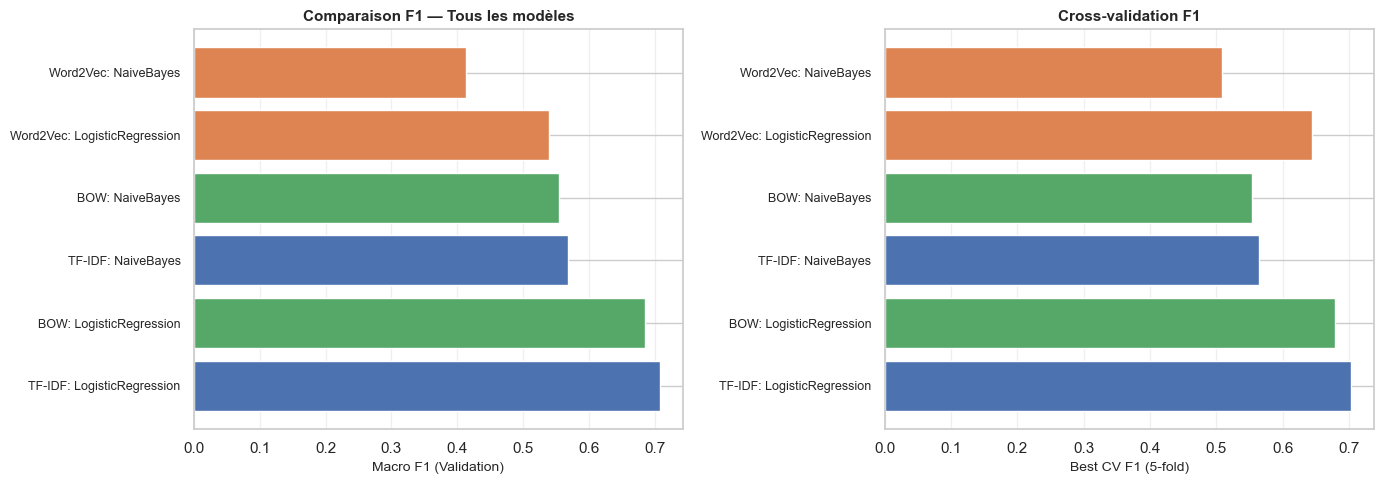

In [36]:
# === COMPARAISON GLOBALE ===
all_results_df = pd.concat(
    [tfidf_results_df, bow_results_df, w2v_results_df],
    ignore_index=True
).sort_values(by="f1_macro", ascending=False)

print("\n" + "="*130)
print("COMPARAISON GLOBALE — Tous les modèles")
print("="*130)

all_display = all_results_df[["vectorizer", "model", "accuracy", "precision_macro", "recall_macro", "f1_macro", "best_cv_f1_macro"]].copy()
for col in ["accuracy", "precision_macro", "recall_macro", "f1_macro", "best_cv_f1_macro"]:
    all_display[col] = all_display[col].round(4)

display(all_display)

print("\n✓ Top 3 meilleures configurations:")
for idx, (i, row) in enumerate(all_display.head(3).iterrows(), 1):
    print(f"  {idx}. {row['vectorizer']:12} + {row['model']:20} → F1: {row['f1_macro']:.4f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sorted_results = all_results_df.reset_index(drop=True)
colors_map = {"TF-IDF": "#4C72B0", "BOW": "#55A868", "Word2Vec": "#DD8452"}
colors_list = [colors_map[v] for v in sorted_results["vectorizer"]]
labels = [f"{row['vectorizer']}: {row['model']}" for _, row in sorted_results.iterrows()]

axes[0].barh(range(len(sorted_results)), sorted_results["f1_macro"], color=colors_list)
axes[0].set_yticks(range(len(sorted_results)))
axes[0].set_yticklabels(labels, fontsize=9)
axes[0].set_xlabel("Macro F1 (Validation)", fontsize=10)
axes[0].set_title("Comparaison F1 — Tous les modèles", fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(range(len(sorted_results)), sorted_results["best_cv_f1_macro"], color=colors_list)
axes[1].set_yticks(range(len(sorted_results)))
axes[1].set_yticklabels(labels, fontsize=9)
axes[1].set_xlabel("Best CV F1 (5-fold)", fontsize=10)
axes[1].set_title("Cross-validation F1", fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


✓ Meilleur modèle: TF-IDF + LogisticRegression
  F1 Validation: 0.7069
  F1 CV (5-fold): 0.7024

✓ RÉSULTATS FINAUX (TEST SET):
  Accuracy: 0.7490
  Macro F1: 0.7101
  Weighted F1: 0.7484

✓ Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.77      0.82      0.79       576
             Bipolar       0.76      0.75      0.75       417
          Depression       0.73      0.64      0.68      2310
              Normal       0.89      0.92      0.90      2444
Personality disorder       0.60      0.65      0.63       161
              Stress       0.52      0.62      0.56       388
            Suicidal       0.64      0.67      0.66      1598

            accuracy                           0.75      7894
           macro avg       0.70      0.72      0.71      7894
        weighted avg       0.75      0.75      0.75      7894



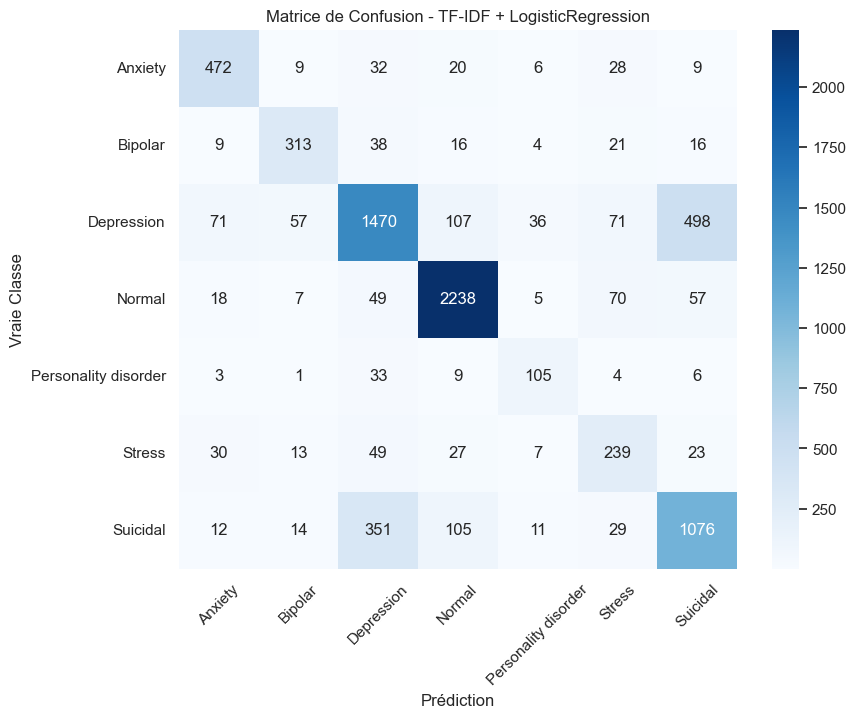

In [37]:
# === SÉLECTION DU MEILLEUR MODÈLE & ÉVALUATION TEST ===
best_row = all_results_df.iloc[0]
best_vectorizer = best_row["vectorizer"]
best_model_name = best_row["model"]

print(f"\n✓ Meilleur modèle: {best_vectorizer} + {best_model_name}")
print(f"  F1 Validation: {best_row['f1_macro']:.4f}")
print(f"  F1 CV (5-fold): {best_row['best_cv_f1_macro']:.4f}")

# Récupérer le modèle entraîné
if best_vectorizer == "TF-IDF":
    best_key = "TFIDF_" + best_model_name
    best_model = trained_tfidf_models[best_key]
    best_X_test = X_test
elif best_vectorizer == "BOW":
    best_key = "BOW_" + best_model_name
    best_model = trained_bow_models[best_key]
    best_X_test = X_test
elif best_vectorizer == "Word2Vec":
    best_key = "W2V_" + best_model_name
    best_model = trained_w2v_models[best_key]
    best_X_test = X_test_w2v

# Évaluation sur test set
test_result, y_pred_test = evaluate_model(
    model_name=best_model_name,
    vectorizer_name=best_vectorizer,
    model=best_model,
    X_eval=best_X_test,
    y_eval_enc=y_test_enc,
    label_encoder=label_encoder
)

print(f"\n✓ RÉSULTATS FINAUX (TEST SET):")
print(f"  Accuracy: {test_result['accuracy']:.4f}")
print(f"  Macro F1: {test_result['f1_macro']:.4f}")
print(f"  Weighted F1: {test_result['f1_weighted']:.4f}")

print(f"\n✓ Classification Report:")
print(classification_report(
    y_test_enc,
    y_pred_test,
    target_names=label_encoder.classes_,
    zero_division=0
))

# Confusion matrix
cm = confusion_matrix(y_test_enc, y_pred_test)
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title(f"Matrice de Confusion - {best_vectorizer} + {best_model_name}")
plt.xlabel("Prédiction")
plt.ylabel("Vraie Classe")
plt.xticks(rotation=45)
plt.show()

✓ Nombre d'erreurs sur test set: 1981/7894
✓ Taux d'erreur: 25.1%

✓ Exemples d'erreurs (20 premiers):


,text,true_label,predicted_label
2,alone no friends think nobody want not know st...,Depression,Suicidal
6,rt NAME knets try describe v look like real life,Suicidal,Normal
7,feel real suicidal no money girlfriend job not...,Suicidal,Depression
9,not clinically depress sorry not right sub mod...,Depression,Suicidal
10,recently feel really strange unsure emotionall...,Depression,Suicidal
13,want kill,Normal,Suicidal
20,lock room avoid hurt others violent breakdown,Suicidal,Normal
25,go pretty rough time morning wake feel sort du...,Suicidal,Depression
29,fuck tire everything tire unhappy not single p...,Depression,Suicidal
35,hi everyone not sure right sub nearly midnight...,Suicidal,Anxiety



✓ Top confusions entre classes:


,true_label,predicted_label,count
17,Depression,Suicidal,498
38,Suicidal,Depression,351
14,Depression,Normal,107
39,Suicidal,Normal,105
16,Depression,Stress,71
12,Depression,Anxiety,71
22,Normal,Stress,70
23,Normal,Suicidal,57
13,Depression,Bipolar,57
32,Stress,Depression,49


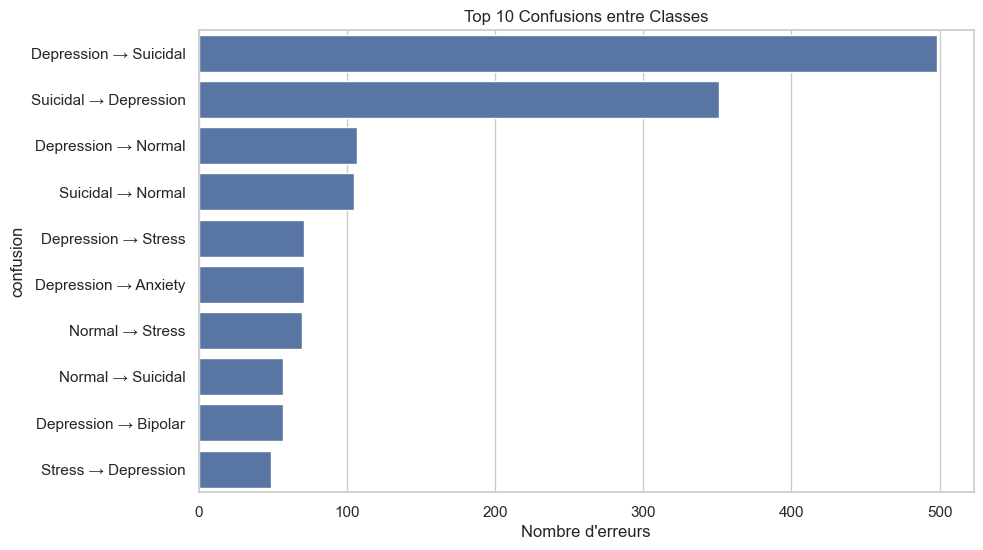

In [38]:
# === ANALYSE DES ERREURS ===
error_df = pd.DataFrame({
    "text": X_test,
    "true_label": label_encoder.inverse_transform(y_test_enc),
    "predicted_label": label_encoder.inverse_transform(y_pred_test)
})

error_df = error_df[error_df["true_label"] != error_df["predicted_label"]].copy()

print(f"✓ Nombre d'erreurs sur test set: {len(error_df)}/{len(X_test)}")
print(f"✓ Taux d'erreur: {(len(error_df)/len(X_test)*100):.1f}%")

print("\n✓ Exemples d'erreurs (20 premiers):")
display(error_df.head(20))

# Confusions principales
confusion_pairs = error_df.groupby(
    ["true_label", "predicted_label"]
).size().reset_index(name="count").sort_values(by="count", ascending=False)

print("\n✓ Top confusions entre classes:")
display(confusion_pairs.head(10))

plt.figure(figsize=(10, 6))
top_confusions = confusion_pairs.head(10).copy()
top_confusions['confusion'] = top_confusions['true_label'] + " → " + top_confusions['predicted_label']
sns.barplot(data=top_confusions, x="count", y="confusion")
plt.title("Top 10 Confusions entre Classes")
plt.xlabel("Nombre d'erreurs")
plt.show()

In [39]:
# === SAUVEGARDE DES RÉSULTATS ===
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

# Sauvegarde du modèle et de l'encodeur
joblib.dump(best_model, "models/best_model_step03.joblib")
joblib.dump(label_encoder, "models/label_encoder_step03.joblib")

# Sauvegarde des résultats
all_results_df.to_csv("outputs/model_comparison_step03.csv", index=False)
error_df.to_csv("outputs/test_errors_step03.csv", index=False)

# Word2Vec
if best_vectorizer == "Word2Vec":
    w2v_model.save("models/word2vec_model_step03.model")
    print("✓ Word2Vec sauvegardé: models/word2vec_model_step03.model")

print("\n✓ Sauvegarde complète:")
print("  • Modèle: models/best_model_step03.joblib")
print("  • Encodeur: models/label_encoder_step03.joblib")
print("  • Comparaison: outputs/model_comparison_step03.csv")
print("  • Erreurs: outputs/test_errors_step03.csv")


✓ Sauvegarde complète:
  • Modèle: models/best_model_step03.joblib
  • Encodeur: models/label_encoder_step03.joblib
  • Comparaison: outputs/model_comparison_step03.csv
  • Erreurs: outputs/test_errors_step03.csv


In [40]:
# === SYNTHÈSE FINALE ===
print("\n" + "="*80)
print("SYNTHÈSE DE L'ÉTAPE 03")
print("="*80)

summary = [
    f"✓ Dataset: {len(X)} textes, {len(label_encoder.classes_)} classes",
    f"✓ Split: Train ({len(X_train)}) | Val ({len(X_val)}) | Test ({len(X_test)})",
    f"✓ Preprocessing: Nettoyage complet + Lemmatization + Stopwords (négations préservées)",
    f"✓ 3 Méthodes de vectorisation testées: TF-IDF, Bag-of-Words, Word2Vec",
    f"✓ 3 Modèles par méthode: Naive Bayes, Logistic Regression, XGBoost",
    f"✓ GridSearchCV avec StratifiedKFold (k=5) et métrique F1 Macro",
    f"",
    f"🏆 MEILLEUR MODÈLE: {best_vectorizer} + {best_model_name}",
    f"  • Validation F1 Macro: {best_row['f1_macro']:.4f}",
    f"  • Test F1 Macro: {test_result['f1_macro']:.4f}",
    f"  • Test Accuracy: {test_result['accuracy']:.4f}",
    f"  • Erreurs sur test: {len(error_df)}/{len(X_test)} ({(len(error_df)/len(X_test)*100):.1f}%)",
    f"",
    f"✓ Résultats sauvegardés dans: models/ et outputs/",
]

for item in summary:
    print(item)


SYNTHÈSE DE L'ÉTAPE 03
✓ Dataset: 52625 textes, 7 classes
✓ Split: Train (36837) | Val (7894) | Test (7894)
✓ Preprocessing: Nettoyage complet + Lemmatization + Stopwords (négations préservées)
✓ 3 Méthodes de vectorisation testées: TF-IDF, Bag-of-Words, Word2Vec
✓ 2 Modèles par méthode: Naive Bayes, Logistic Regression
✓ GridSearchCV avec StratifiedKFold (k=5) et métrique F1 Macro

🏆 MEILLEUR MODÈLE: TF-IDF + LogisticRegression
  • Validation F1 Macro: 0.7069
  • Test F1 Macro: 0.7101
  • Test Accuracy: 0.7490
  • Erreurs sur test: 1981/7894 (25.1%)

✓ Résultats sauvegardés dans: models/ et outputs/
